# Xarray Advanced

In this lesson we go beyond the basics — **interpolation, `groupby`, `resample`, `rolling`, and `coarsen`** — and apply them to a real sea-surface-temperature dataset to build climatologies and anomalies, the bread and butter of climate analysis.

:::{admonition} Working through this notebook
:class: tip
This page is a Jupyter notebook. **Download it** using the ⬇ button in the top-right (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and step through the cells. When you reach a **Try it** admonition, experiment in your own cells before moving on.
:::

:::{admonition} In-class assignment — 10 points
:class: note
The **"Try it"** exercises in this notebook are part of your in-class assignment for this section. Complete them in your own copy of the notebook, push it to your week folder, and post the notebook link on the matching **Courseworks** assignment. (One 10-point assignment covers all the lecture notebooks in this section.)
:::

In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
%xmode Minimal

Exception reporting mode: Minimal


## Interpolation

In the previous lesson on Xarray, we learned how to select data based on its dimension coordinates and align data with different coordinates.
But what if we want to estimate the value of the data variables at _different coordinates_.
This is where interpolation comes in.

In [2]:
# we write it out explicitly so we can see each point.
x_data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
f = xr.DataArray(x_data**2, dims=['x'], coords={'x': x_data})
f

<xarray.DataArray (x: 11)> Size: 88B
array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100])
Coordinates:
  * x        (x) int64 88B 0 1 2 3 4 5 6 7 8 9 10

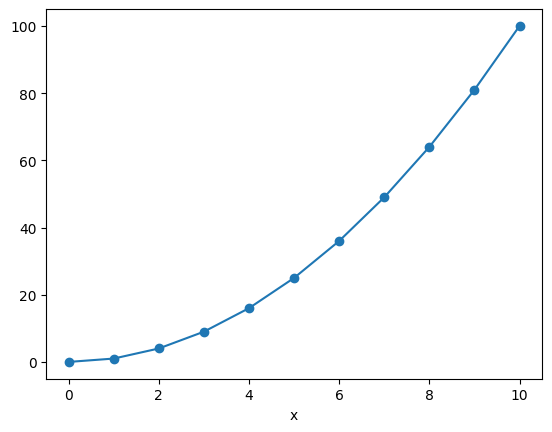

In [3]:
f.plot(marker='o')

In [4]:
f.sel(x=4)

<xarray.DataArray ()> Size: 8B
array(16)
Coordinates:
    x        int64 8B 4

We only have data on the integer points in x.
But what if we wanted to estimate the value at, say, 4.5?

In [5]:
f.sel(x=4.5)

KeyError: "not all values found in index 'x'. Try setting the `method` keyword argument (example: method='nearest')."

Interpolation to the rescue!

In [6]:
f.sel(x=4), f.sel(x=5)

(<xarray.DataArray ()> Size: 8B
 array(16)
 Coordinates:
     x        int64 8B 4,
 <xarray.DataArray ()> Size: 8B
 array(25)
 Coordinates:
     x        int64 8B 5)

In [7]:
f.interp(x=4.5)

<xarray.DataArray ()> Size: 8B
array(20.5)
Coordinates:
    x        float64 8B 4.5

Interpolation uses [scipy.interpolate](https://docs.scipy.org/doc/scipy/reference/interpolate.html) under the hood.
There are different modes of interpolation.

In [8]:
# default
f.interp(x=4.5, method='linear').values

array(20.5)

In [9]:
f.interp(x=4.5, method='nearest').values

array(16.)

In [10]:
f.interp(x=4.5, method='cubic').values

array(20.25)

We can interpolate to a whole new coordinate at once:

In [11]:
x_new = x_data + 0.5

In [12]:
f_interp_linear = f.interp(x=x_new, method='linear')
f_interp_cubic = f.interp(x=x_new, method='cubic')

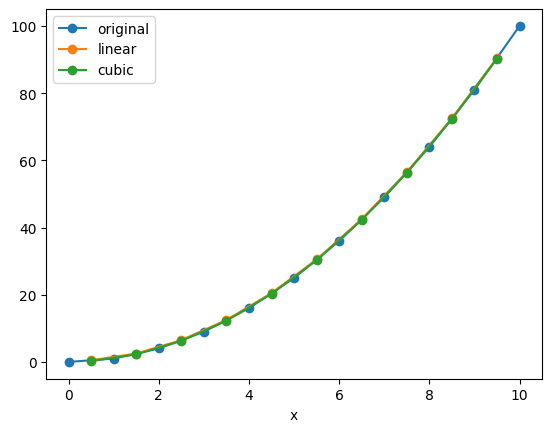

In [13]:
f.plot(marker='o', label='original')
f_interp_linear.plot(marker='o', label='linear')
f_interp_cubic.plot(marker='o', label='cubic')
plt.legend()

Note that values outside of the original range are not supported:

In [14]:
f_interp_linear.values

array([ 0.5,  2.5,  6.5, 12.5, 20.5, 30.5, 42.5, 56.5, 72.5, 90.5,  nan])

```{note}
You can apply interpolation to any dimension, and even to multiple dimensions at a time.
(Multidimensional interpolation only supports `mode='nearest'` and `mode='linear'`.)
But keep in mind that _Xarray has no built-in understanding of geography_.
If you use `interp` on lat / lon coordinates, it will just perform naive interpolation of the lat / lon values.
More sophisticated treatment of spherical geometry requires another package such as [xesmf](https://xesmf.readthedocs.io/).
```

:::{admonition} Try it
:class: tip
Take the `f = x**2` DataArray (or build your own). Use `.interp()` to estimate its value at a non-integer point (e.g. `x=4.5`), comparing `method='linear'`, `'nearest'`, and `'cubic'`. Then interpolate `f` onto a whole new set of x-values and plot the original vs. interpolated curves.
:::

## Groupby

Xarray copies Pandas' very useful groupby functionality, enabling the "split / apply / combine" workflow on xarray DataArrays and Datasets. In the first part of the lesson, we will learn to use groupby by analyzing sea-surface temperature data.

First we load a dataset. We will use the [NOAA Extended Reconstructed Sea Surface Temperature (ERSST) v5](https://www.ncdc.noaa.gov/data-access/marineocean-data/extended-reconstructed-sea-surface-temperature-ersst-v5) product, a widely used and trusted gridded compilation of of historical data going back to 1854.

Since the data is provided via an [OPeNDAP](https://en.wikipedia.org/wiki/OPeNDAP) server, we can load it directly without downloading anything:

In [15]:
url = 'https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'
# Read the data in small time-chunks (uses dask). Pulling the whole array in
# one OPeNDAP request makes this THREDDS server return all-zeros (blank maps);
# chunking fetches it piece-by-piece, then .load() brings it into memory.
ds = xr.open_dataset(url, drop_variables=['time_bnds'], chunks={'time': 120})
ds = ds.sel(time=slice('1960', '2018')).load()
ds

<xarray.Dataset> Size: 45MB
Dimensions:  (time: 708, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lat, lon) float32 45MB -1.8 -1.8 -1.8 -1.8 ... nan nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

Let's do some basic visualizations of the data, just to make sure it looks reasonable.

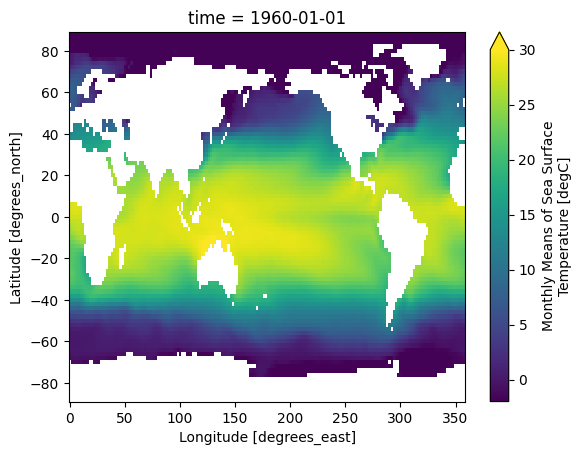

In [16]:
ds.sst[0].plot(vmin=-2, vmax=30)

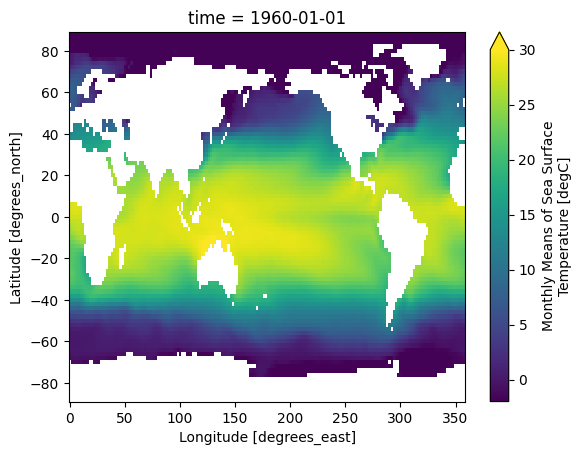

In [17]:
ds.sst.isel(time=0).plot(vmin=-2, vmax=30)

Note that xarray correctly parsed the time index, resulting in a Pandas datetime index on the time dimension.

In [18]:
ds.time

<xarray.DataArray 'time' (time: 708)> Size: 6kB
array(['1960-01-01T00:00:00.000000000', '1960-02-01T00:00:00.000000000',
       '1960-03-01T00:00:00.000000000', ..., '2018-10-01T00:00:00.000000000',
       '2018-11-01T00:00:00.000000000', '2018-12-01T00:00:00.000000000'],
      shape=(708,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
Attributes:
    long_name:        Time
    delta_t:          0000-01-00 00:00:00
    avg_period:       0000-01-00 00:00:00
    prev_avg_period:  0000-00-07 00:00:00
    standard_name:    time
    axis:             T
    actual_range:     [19723. 82665.]
    _ChunkSizes:      1

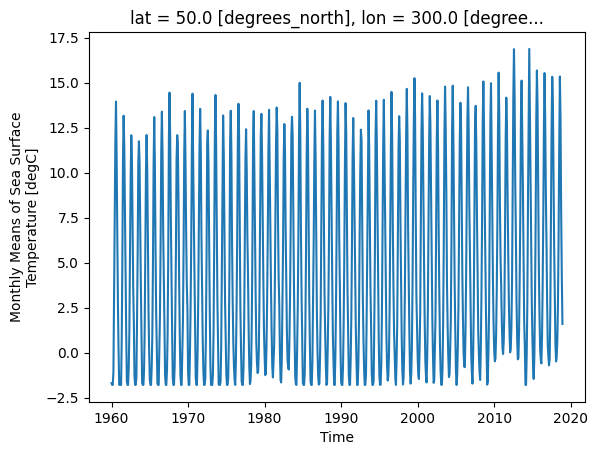

In [19]:
ds.sst.sel(lon=300, lat=50).plot()

As we can see from the plot, the timeseries at any one point is totally dominated by the seasonal cycle. We would like to remove this seasonal cycle (called the "climatology") in order to better see the long-term variations in temperature. We will accomplish this using **groupby**.

The syntax of Xarray's groupby is almost identical to Pandas.
We will first apply groupby to a single DataArray.

In [20]:
ds.sst.groupby?

### Split Step

The most important argument is `group`: this defines the unique values we will use to "split" the data for grouped analysis. We can pass either a DataArray or a name of a variable in the dataset. Lets first use a DataArray. Just like with Pandas, we can use the time index to extract specific components of dates and times. Xarray uses a special syntax for this `.dt`, called the `DatetimeAccessor`.

In [21]:
ds.time

<xarray.DataArray 'time' (time: 708)> Size: 6kB
array(['1960-01-01T00:00:00.000000000', '1960-02-01T00:00:00.000000000',
       '1960-03-01T00:00:00.000000000', ..., '2018-10-01T00:00:00.000000000',
       '2018-11-01T00:00:00.000000000', '2018-12-01T00:00:00.000000000'],
      shape=(708,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
Attributes:
    long_name:        Time
    delta_t:          0000-01-00 00:00:00
    avg_period:       0000-01-00 00:00:00
    prev_avg_period:  0000-00-07 00:00:00
    standard_name:    time
    axis:             T
    actual_range:     [19723. 82665.]
    _ChunkSizes:      1

In [22]:
ds.time.dt.month

<xarray.DataArray 'month' (time: 708)> Size: 6kB
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,
...
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
Attributes:
    long_name:        Time
    delta_t:          0000-01-00 00:00:00
    avg_period:       0000-01-00 00:00:00
    prev_avg_period:  0000-00-07 00:00:00
    standard_name:    time
    axis:             T
    actual_range:     [19723. 82665.]
    _ChunkSizes:      1

In [23]:
ds.time.dt.year

<xarray.DataArray 'year' (time: 708)> Size: 6kB
array([1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960,
       1960, 1961, 1961, 1961, 1961, 1961, 1961, 1961, 1961, 1961, 1961,
       1961, 1961, 1962, 1962, 1962, 1962, 1962, 1962, 1962, 1962, 1962,
       1962, 1962, 1962, 1963, 1963, 1963, 1963, 1963, 1963, 1963, 1963,
       1963, 1963, 1963, 1963, 1964, 1964, 1964, 1964, 1964, 1964, 1964,
       1964, 1964, 1964, 1964, 1964, 1965, 1965, 1965, 1965, 1965, 1965,
       1965, 1965, 1965, 1965, 1965, 1965, 1966, 1966, 1966, 1966, 1966,
       1966, 1966, 1966, 1966, 1966, 1966, 1966, 1967, 1967, 1967, 1967,
       1967, 1967, 1967, 1967, 1967, 1967, 1967, 1967, 1968, 1968, 1968,
       1968, 1968, 1968, 1968, 1968, 1968, 1968, 1968, 1968, 1969, 1969,
       1969, 1969, 1969, 1969, 1969, 1969, 1969, 1969, 1969, 1969, 1970,
       1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970, 1970,
       1971, 1971, 1971, 1971, 1971, 1971, 1971, 1971, 1971, 1971, 1971,
       1971, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972,
       1972, 1972, 1973, 1973, 1973, 1973, 1973, 1973, 1973, 1973, 1973,
       1973, 1973, 1973, 1974, 1974, 1974, 1974, 1974, 1974, 1974, 1974,
       1974, 1974, 1974, 1974, 1975, 1975, 1975, 1975, 1975, 1975, 1975,
       1975, 1975, 1975, 1975, 1975, 1976, 1976, 1976, 1976, 1976, 1976,
       1976, 1976, 1976, 1976, 1976, 1976, 1977, 1977, 1977, 1977, 1977,
       1977, 1977, 1977, 1977, 1977, 1977, 1977, 1978, 1978, 1978, 1978,
...
       2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2002, 2002,
       2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2003,
       2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003,
       2004, 2004, 2004, 2004, 2004, 2004, 2004, 2004, 2004, 2004, 2004,
       2004, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005,
       2005, 2005, 2006, 2006, 2006, 2006, 2006, 2006, 2006, 2006, 2006,
       2006, 2006, 2006, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007,
       2007, 2007, 2007, 2007, 2008, 2008, 2008, 2008, 2008, 2008, 2008,
       2008, 2008, 2008, 2008, 2008, 2009, 2009, 2009, 2009, 2009, 2009,
       2009, 2009, 2009, 2009, 2009, 2009, 2010, 2010, 2010, 2010, 2010,
       2010, 2010, 2010, 2010, 2010, 2010, 2010, 2011, 2011, 2011, 2011,
       2011, 2011, 2011, 2011, 2011, 2011, 2011, 2011, 2012, 2012, 2012,
       2012, 2012, 2012, 2012, 2012, 2012, 2012, 2012, 2012, 2013, 2013,
       2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2014,
       2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014,
       2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015,
       2015, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016,
       2016, 2016, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017,
       2017, 2017, 2017, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018,
       2018, 2018, 2018, 2018])
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
Attributes:
    long_name:        Time
    delta_t:          0000-01-00 00:00:00
    avg_period:       0000-01-00 00:00:00
    prev_avg_period:  0000-00-07 00:00:00
    standard_name:    time
    axis:             T
    actual_range:     [19723. 82665.]
    _ChunkSizes:      1

We can use these arrays in a groupby operation:

In [24]:
gb = ds.sst.groupby(ds.time.dt.month)
gb

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

Xarray also offers a more concise syntax when the variable you're grouping on is already present in the dataset. This is identical to the previous line:

In [25]:
gb = ds.sst.groupby('time.month')
gb

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

Now that the data are split, we can manually iterate over the group. The iterator returns the key (group name) and the value (the actual dataset corresponding to that group) for each group.

In [26]:
for group_name, group_da in gb:
    # stop iterating after the first loop
    break 
print(group_name)
group_da

1


<xarray.DataArray 'sst' (time: 59, lat: 89, lon: 180)> Size: 4MB
array([[[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        ...,
...
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]],
      shape=(59, 89, 180), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 472B 1960-01-01 1961-01-01 ... 2018-01-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

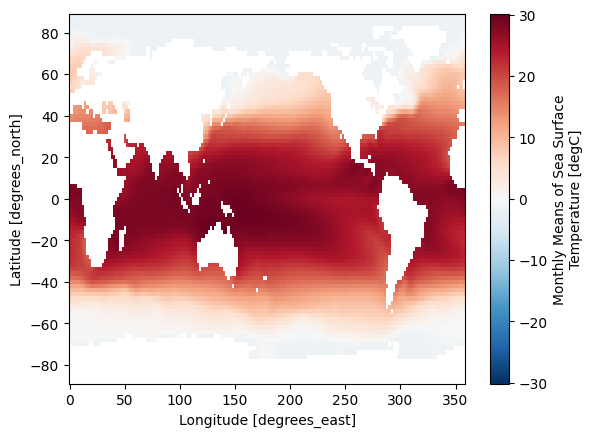

In [27]:
group_da.mean('time').plot()

### Map & Combine

Now that we have groups defined, it's time to "apply" a calculation to the group. Like in Pandas, these calculations can either be:
- _aggregation_: reduces the size of the group
- _transformation_: preserves the group's full size

At the end of the apply step, xarray will automatically combine the aggregated / transformed groups back into a single object.

```{warning}
Xarray calls the "apply" step `map`. This is different from Pandas!
```

The most fundamental way to apply is with the `.map` method.

In [28]:
gb.map?

#### Aggregations

`.map` accepts as its argument a function. We can pass an existing function:

In [29]:
gb.map(np.mean)

<xarray.DataArray 'sst' (month: 12)> Size: 48B
array([13.659839, 13.768812, 13.765059, 13.68421 , 13.642344, 13.712949,
       13.921948, 14.094091, 13.982345, 13.691327, 13.506662, 13.529607],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

Because we specified no extra arguments (like `axis`) the function was applied over all space and time dimensions. This is not what we wanted. Instead, we could define a custom function. This function takes a single argument--the group dataset--and returns a new dataset to be combined:

In [30]:
def time_mean(a):
    return a.mean(dim='time')

gb.map(time_mean)

<xarray.DataArray 'sst' (month: 12, lat: 89, lon: 180)> Size: 769kB
array([[[-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.7995427, -1.799635 , -1.7998594, ..., -1.7997919,
         -1.7996687, -1.7995385],
        [-1.7995995, -1.7997797, -1.8000009, ..., -1.8000009,
         -1.7998233, -1.7996242],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(12, 89, 180), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

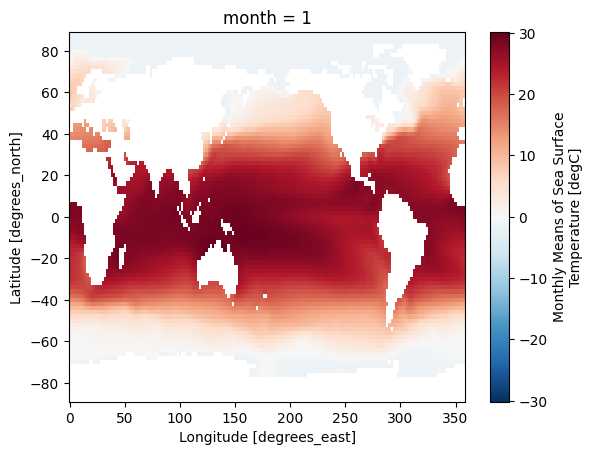

In [31]:
gb.map(time_mean).sel(month=1).plot()

Like Pandas, xarray's groupby object has many built-in aggregation operations (e.g. `mean`, `min`, `max`, `std`, etc):

In [32]:
# this does the same thing as the previous cell
sst_mm = gb.mean('time')
sst_mm

<xarray.DataArray 'sst' (month: 12, lat: 89, lon: 180)> Size: 769kB
array([[[-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.7995427, -1.799635 , -1.7998594, ..., -1.7997919,
         -1.7996687, -1.7995385],
        [-1.7995995, -1.7997797, -1.8000009, ..., -1.8000009,
         -1.7998233, -1.7996242],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(12, 89, 180), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

So we did what we wanted to do: calculate the climatology at every point in the dataset. Let's look at the data a bit.

_Climatology at a specific point in the North Atlantic_

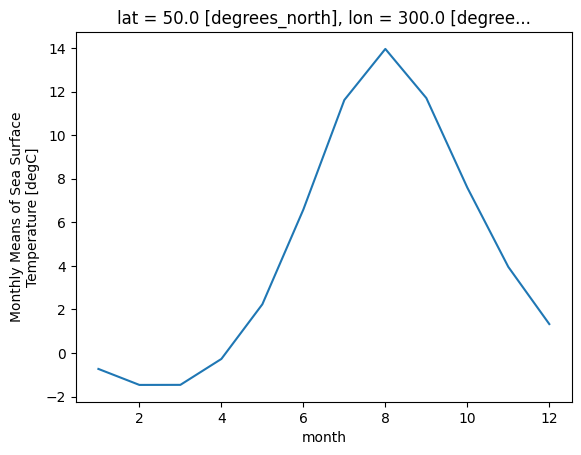

In [33]:
sst_mm.sel(lon=300, lat=50).plot()

_Zonal Mean Climatology_

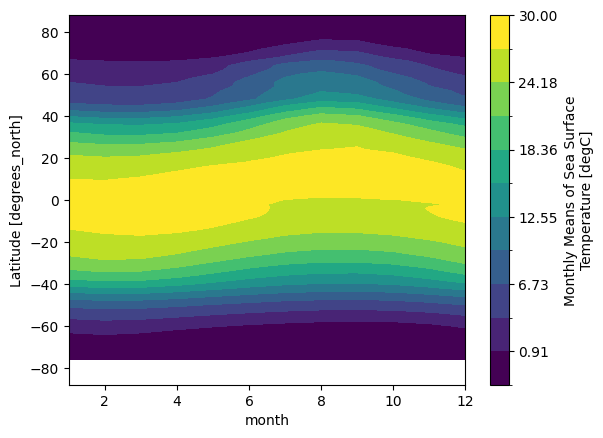

In [34]:
sst_mm.mean(dim='lon').transpose().plot.contourf(levels=12, vmin=-2, vmax=30)

_Difference between January and July Climatology_

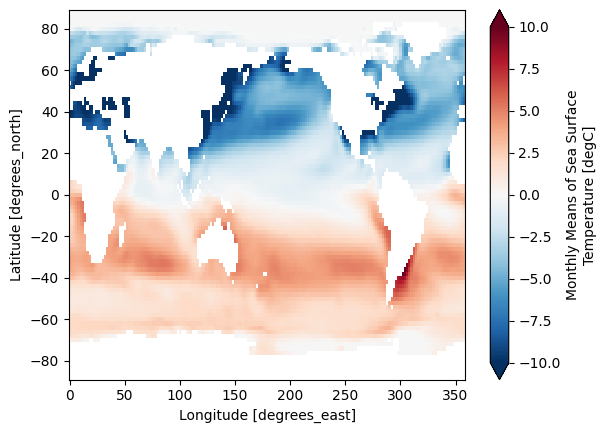

In [35]:
(sst_mm.sel(month=1) - sst_mm.sel(month=7)).plot(vmax=10)

#### Transformations

Now we want to _remove_ this climatology from the dataset, to examine the residual, called the _anomaly_, which is the interesting part from a climate perspective.
Removing the seasonal climatology is a perfect example of a transformation: it operates over a group, but doesn't change the size of the dataset. Here is one way to code it.

In [36]:
def remove_time_mean(x):
    return x - x.mean(dim='time')

ds_anom = ds.groupby('time.month').map(remove_time_mean)
ds_anom

<xarray.Dataset> Size: 45MB
Dimensions:  (time: 708, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lat, lon) float32 45MB 9.537e-07 9.537e-07 ... nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

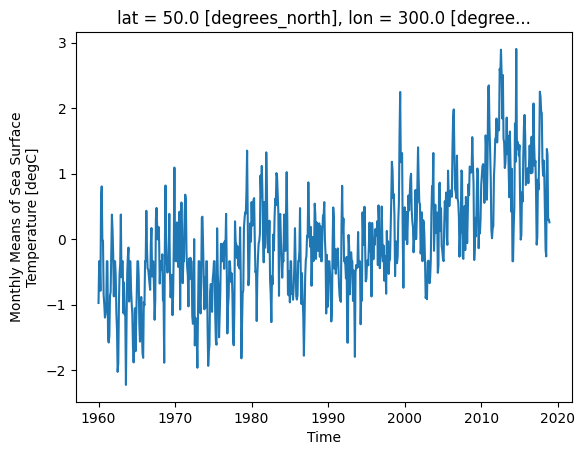

In [37]:
ds_anom.sst.sel(lon=300, lat=50).plot()

```{note}
In the above example, we applied `groupby` to a `Dataset` instead of a `DataArray`.
```

Xarray makes these sorts of transformations easy by supporting _groupby arithmetic_.
This concept is easiest explained with an example:

In [38]:
gb = ds.groupby('time.month')
ds_anom = gb - gb.mean(dim='time')
ds_anom

<xarray.Dataset> Size: 45MB
Dimensions:  (lat: 89, lon: 180, time: 708)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
    month    (time) int64 6kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 45MB 9.537e-07 9.537e-07 ... nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

Now we can view the climate signal without the overwhelming influence of the seasonal cycle.

_Timeseries at a single point in the North Atlantic_

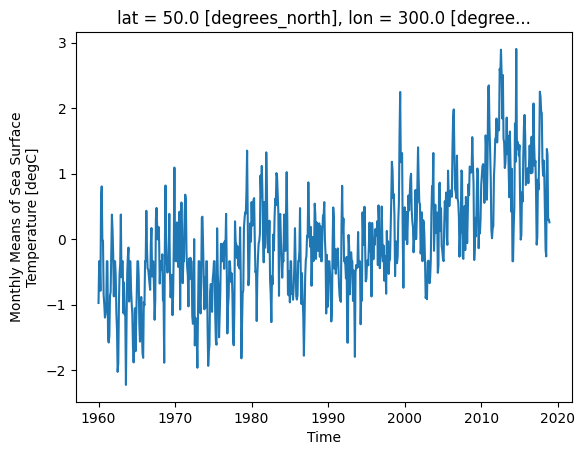

In [39]:
ds_anom.sst.sel(lon=300, lat=50).plot()

_Difference between Jan. 1 2018 and Jan. 1 1960_

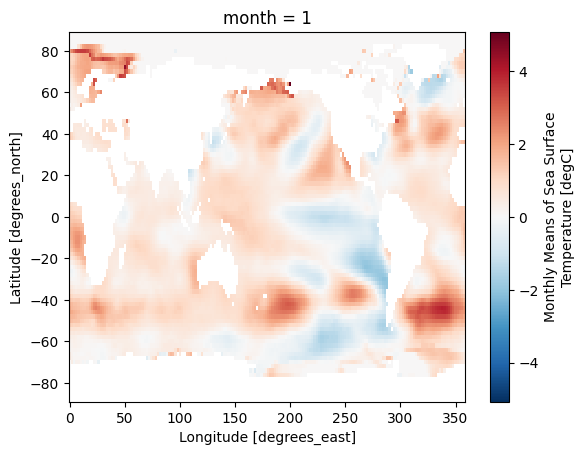

In [40]:
(ds_anom.sel(time='2018-01-01') - ds_anom.sel(time='1960-01-01')).sst.plot()

:::{admonition} Try it
:class: tip
Using the SST `ds`, build the monthly **climatology** with `ds.sst.groupby('time.month').mean('time')` and plot it at a point of your choice. Then compute the **anomaly** with groupby arithmetic (`gb - gb.mean('time')`) and plot its timeseries at the same point — the seasonal cycle should be gone.
:::

## Groupby-Related: Resample, Rolling, Coarsen


### Resample

Resample in xarray is nearly identical to Pandas.
**It can be applied only to time-index dimensions.** Here we compute the five-year mean.
It is effectively a group-by operation, and uses the same basic syntax.
Note that resampling changes the length of the output arrays.

In [41]:
ds_anom

<xarray.Dataset> Size: 45MB
Dimensions:  (lat: 89, lon: 180, time: 708)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
    month    (time) int64 6kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 45MB 9.537e-07 9.537e-07 ... nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

In [42]:
ds_anom_resample = ds_anom.resample(time='5YE').mean(dim='time')
ds_anom_resample

<xarray.Dataset> Size: 834kB
Dimensions:  (time: 13, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 104B 1960-12-31 1965-12-31 ... 2020-12-31
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lat, lon) float32 833kB -0.0005207 -0.0004956 ... nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

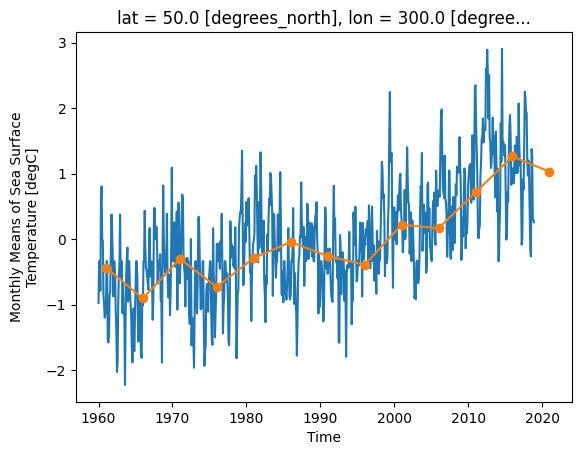

In [43]:
ds_anom.sst.sel(lon=300, lat=50).plot()
ds_anom_resample.sst.sel(lon=300, lat=50).plot(marker='o')

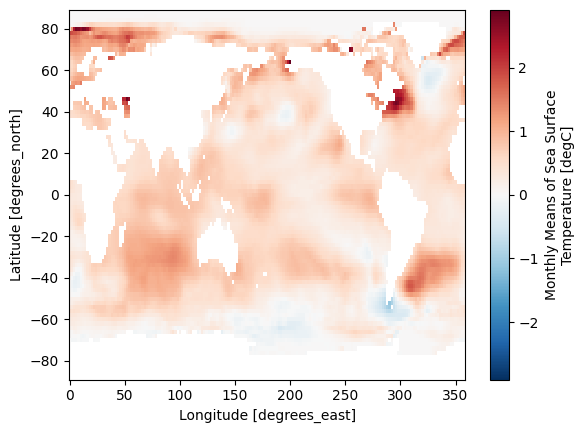

In [44]:
(ds_anom_resample.sel(time='2015-01-01', method='nearest') -
 ds_anom_resample.sel(time='1965-01-01', method='nearest')).sst.plot()

### Rolling

Rolling is also similar to pandas.
It does not change the length of the arrays.
Instead, it allows a moving window to be applied to the data at each point.

In [45]:
ds_anom_rolling = ds_anom.rolling(time=60, center=True).mean()
ds_anom_rolling

<xarray.Dataset> Size: 45MB
Dimensions:  (lat: 89, lon: 180, time: 708)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
    month    (time) int64 6kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 45MB nan nan nan nan ... nan nan nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

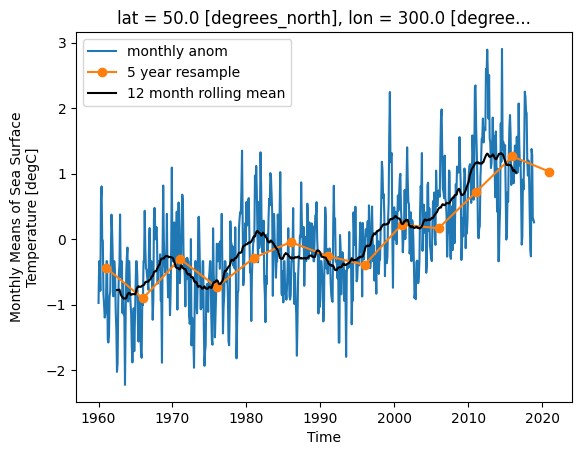

In [46]:
ds_anom.sst.sel(lon=300, lat=50).plot(label='monthly anom')
ds_anom_resample.sst.sel(lon=300, lat=50).plot(marker='o', label='5 year resample')
ds_anom_rolling.sst.sel(lon=300, lat=50).plot(label='12 month rolling mean', color='k')
plt.legend()

:::{admonition} Try it
:class: tip
Take the SST anomaly at a single point. `resample(time='1YE').mean()` it to annual means and plot, then overlay a `rolling(time=12, center=True).mean()` of the monthly series on the same axes. How do the two smoothings differ?
:::

## Coarsen

`coarsen` is a simple way to reduce the size of your data along one or more axes.
It is very similar to `resample` when operating on time dimensions; the key difference is that `coarsen` only operates on fixed blocks of data, irrespective of the coordinate values, while `resample` actually looks at the coordinates to figure out, e.g. what month a particular data point is in. 

For regularly-spaced monthly data beginning in January, the following should be equivalent to annual resampling.
However, results would different for irregularly-spaced data.

In [47]:
ds.coarsen(time=12).mean()

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 59, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 472B 1960-06-16T08:00:00 ... 2018-06-16T12...
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lat, lon) float32 4MB -1.8 -1.8 -1.8 -1.8 ... nan nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

Coarsen also works on spatial coordinates (or any coordinates).

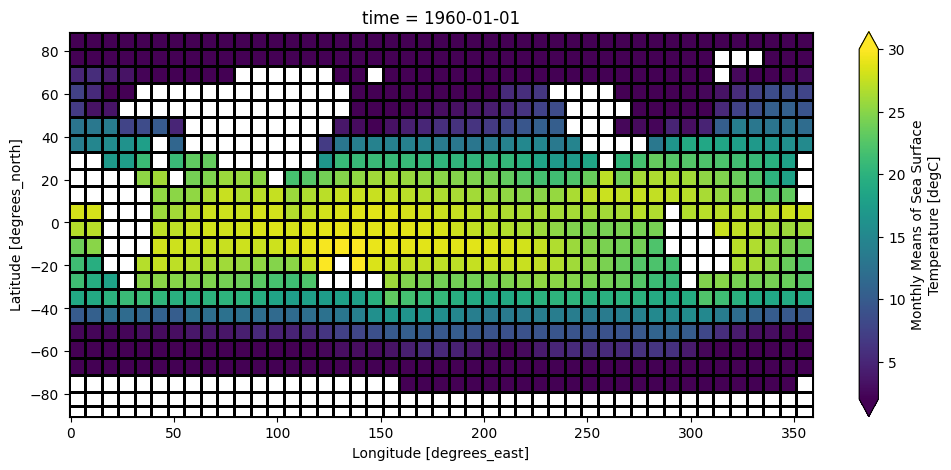

In [48]:
ds_coarse = ds.coarsen(lon=4, lat=4, boundary='pad').mean()
ds_coarse.sst.isel(time=0).plot(vmin=2, vmax=30, figsize=(12, 5), edgecolor='k')

:::{admonition} Try it
:class: tip
Use `ds.coarsen(lon=4, lat=4, boundary='pad').mean()` to coarsen the SST map and plot one time step. Then use `ds.coarsen(time=12).mean()` to make annual-block means, and compare with the `resample` result above.
:::

## An Advanced Example

In this example we will show a realistic workflow with Xarray.
We will
- Load a "basin mask" dataset
- Interpolate the basins to our SST dataset coordinates
- Group the SST by basin
- Convert to Pandas Dataframe and plot mean SST by basin

In [49]:
basin = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NODC/.WOA09/.Masks/.basin/dods')
basin

<xarray.Dataset> Size: 9MB
Dimensions:  (Z: 33, Y: 180, X: 360)
Coordinates:
  * Z        (Z) float32 132B 0.0 10.0 20.0 30.0 ... 4e+03 4.5e+03 5e+03 5.5e+03
  * Y        (Y) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * X        (X) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    basin    (Z, Y, X) float32 9MB ...
Attributes:
    Conventions:  IRIDL

In [50]:
basin = basin.rename({'X': 'lon', 'Y': 'lat'})
basin

<xarray.Dataset> Size: 9MB
Dimensions:  (Z: 33, lat: 180, lon: 360)
Coordinates:
  * Z        (Z) float32 132B 0.0 10.0 20.0 30.0 ... 4e+03 4.5e+03 5e+03 5.5e+03
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    basin    (Z, lat, lon) float32 9MB ...
Attributes:
    Conventions:  IRIDL

In [51]:
basin_surf = basin.basin[0]
basin_surf

<xarray.DataArray 'basin' (lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    Z        float32 4B 0.0
Attributes:
    long_name:  basin code
    units:      ids
    scale_max:  58
    CLIST:      Atlantic Ocean\nPacific Ocean \nIndian Ocean\nMediterranean S...
    valid_min:  1
    valid_max:  58
    scale_min:  1

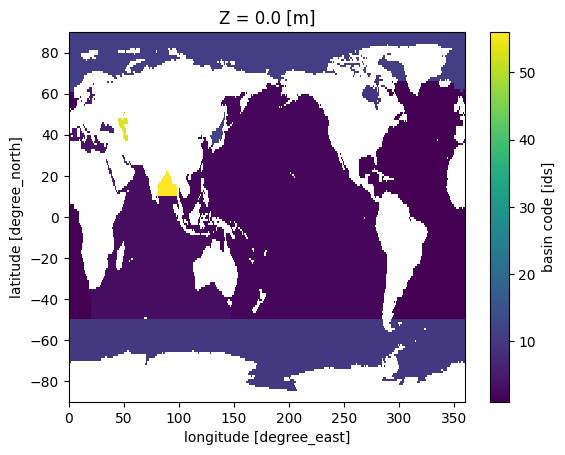

In [52]:
basin_surf.plot()

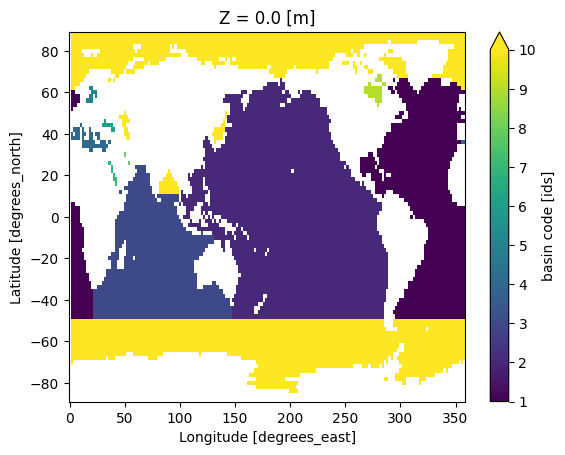

In [53]:
basin_surf_interp = basin_surf.interp_like(ds.sst, method='nearest')
basin_surf_interp.plot(vmax=10)

In [54]:
ds.sst.groupby(basin_surf_interp).first()

<xarray.DataArray 'sst' (time: 708, basin: 14)> Size: 40kB
array([[-1.8       , -1.8       , 23.455315  , ..., -1.8       ,
         3.3971915 , 24.182198  ],
       [-1.8       , -1.8       , 23.722523  , ..., -1.8       ,
         0.03573781, 24.59657   ],
       [-1.8       , -1.8       , 24.601315  , ..., -1.8       ,
        -0.26487017, 26.234186  ],
       ...,
       [ 0.7450514 ,  6.4851065 , 29.284546  , ..., 10.81646   ,
        15.956354  , 29.394825  ],
       [-0.7308574 ,  3.0851452 , 27.611626  , ...,  5.2929263 ,
        10.659401  , 27.718332  ],
       [-1.8       , -0.04102494, 25.885515  , ...,  0.40815616,
         7.2586193 , 26.130033  ]], shape=(708, 14), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
  * basin    (basin) float32 56B 1.0 2.0 3.0 4.0 5.0 ... 11.0 12.0 53.0 56.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

In [55]:
basin_mean_sst = ds.sst.groupby(basin_surf_interp).mean()
basin_mean_sst

<xarray.DataArray 'sst' (time: 708, basin: 14)> Size: 40kB
array([[18.585493 , 20.757555 , 21.572067 , ...,  6.238062 ,  6.889794 ,
        26.49982  ],
       [18.705065 , 20.81674  , 21.902279 , ...,  4.8877654,  5.44638  ,
        26.577093 ],
       [18.845842 , 20.865038 , 22.031416 , ...,  4.686406 ,  5.5322194,
        27.908558 ],
       ...,
       [19.852085 , 21.963287 , 20.39205  , ..., 17.57406  , 18.205872 ,
        29.347967 ],
       [19.426289 , 21.726622 , 21.064245 , ..., 13.463712 , 13.879008 ,
        28.76069  ],
       [19.267078 , 21.515337 , 21.816973 , ...,  9.416823 , 10.623679 ,
        27.910095 ]], shape=(708, 14), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1960-01-01 1960-02-01 ... 2018-12-01
  * basin    (basin) float32 56B 1.0 2.0 3.0 4.0 5.0 ... 11.0 12.0 53.0 56.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

In [56]:
df = basin_mean_sst.mean('time').to_dataframe()
df

,sst
basin,
1.0,19.285189
2.0,21.178280
3.0,21.127195
4.0,19.846029
5.0,8.132305
6.0,15.082543
7.0,28.494074
8.0,26.617857
9.0,0.310967


In [57]:
import pandas as pd
basin_names = basin_surf.attrs['CLIST'].split('\n')
basin_df = pd.Series(basin_names, index=np.arange(1, len(basin_names)+1))
basin_df

1                 Atlantic Ocean
2                 Pacific Ocean 
3                   Indian Ocean
4              Mediterranean Sea
5                     Baltic Sea
6                      Black Sea
7                        Red Sea
8                   Persian Gulf
9                     Hudson Bay
10                Southern Ocean
11                  Arctic Ocean
12                  Sea of Japan
13                      Kara Sea
14                      Sulu Sea
15                    Baffin Bay
16            East Mediterranean
17            West Mediterranean
18                Sea of Okhotsk
19                     Banda Sea
20                 Caribbean Sea
21                 Andaman Basin
22               North Caribbean
23                Gulf of Mexico
24                  Beaufort Sea
25               South China Sea
26                   Barents Sea
27                   Celebes Sea
28                Aleutian Basin
29                    Fiji Basin
30          North American Basin
31        

In [58]:
df = df.join(basin_df.rename('basin_name'))

<Axes: xlabel='basin_name'>

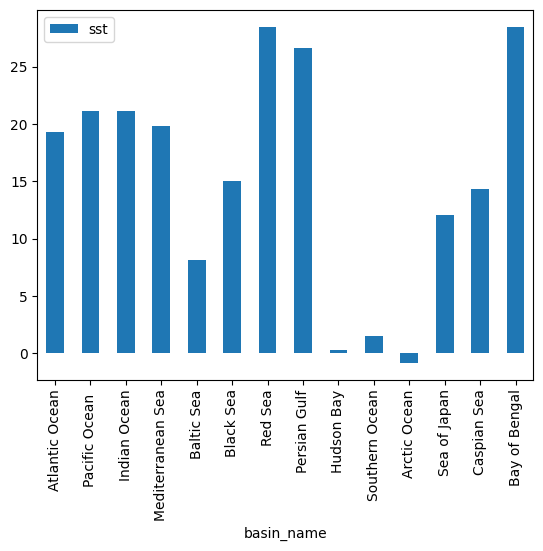

In [59]:
df.plot.bar(y='sst', x='basin_name')

## Recap

This notebook applied xarray to a real SST dataset and covered its more advanced tools:

- **Interpolation** — `.interp()` to estimate values at new coordinates (`linear`/`nearest`/`cubic`), in one or more dimensions.
- **Groupby** — split-apply-combine on grids: building a monthly **climatology** and removing it to get **anomalies**, with both `.map(...)` and groupby arithmetic.
- **Resample, rolling, coarsen** — change time resolution by calendar (`resample`), smooth with a moving window (`rolling`), or average fixed blocks (`coarsen`).
- **A full workflow** — masking SST by ocean basin (interpolating a basin mask onto the grid), grouping by basin, and summarizing into a table and bar chart.

With pandas and xarray you now have the core toolkit for tabular and gridded data. The [SST lab (Assignment 6)](./assignment6.ipynb) is your at-home assignment.